## Data Processing

In [3]:
import pandas as pd

# load
df = pd.read_csv(
    "/kaggle/input/datasets/xocelyk/nba-pbp/all_games.csv",
    low_memory=False
)

# reduce size (for speed)
df = df.head(500000)

# select home lineup
home_cols = ["H1", "H2", "H3", "H4", "H5"]
df = df.dropna(subset=home_cols).copy()

# build lineup
df["lineup"] = list(zip(df["H1"], df["H2"], df["H3"], df["H4"], df["H5"]))

# convert score
df["HomeScore"] = pd.to_numeric(df["HomeScore"], errors="coerce")
df["AwayScore"] = pd.to_numeric(df["AwayScore"], errors="coerce")

# sort (CRITICAL)
df = df.sort_values(
    ["GameID", "Period", "Time"],
    ascending=[True, True, False] 
)

# compute points
df["home_diff"] = df.groupby("GameID")["HomeScore"].diff().fillna(0)
df["away_diff"] = df.groupby("GameID")["AwayScore"].diff().fillna(0)

df["points"] = df["home_diff"] + df["away_diff"]
df["points"] = df["points"].clip(lower=0).fillna(0)

# aggregate
lineup_stats = df.groupby("lineup").agg(
    total_points=("points", "sum"),
    total_events=("points", "count")
).reset_index()

# PPP
lineup_stats["PPP"] = lineup_stats["total_points"] / lineup_stats["total_events"]

# filter
lineup_stats = lineup_stats[lineup_stats["total_events"] >= 20]

# label
q_high = lineup_stats["PPP"].quantile(0.75)
q_low = lineup_stats["PPP"].quantile(0.25)

def label(ppp):
    if ppp >= q_high:
        return "high"
    elif ppp <= q_low:
        return "low"
    else:
        return "mid"

lineup_stats["label"] = lineup_stats["PPP"].apply(label)

# players list
lineup_stats["players"] = lineup_stats["lineup"].apply(list)

print(lineup_stats.head())
print(lineup_stats["label"].value_counts())
print("Total lineups:", len(lineup_stats))





                                              lineup  total_points  \
0  (abdursh01, dickemi01, austiis01, bibbymi01, h...          69.0   
2  (abdursh01, dickemi01, bibbymi01, harriot01, l...          45.0   
7  (abdursh01, dickemi01, swiftst01, bibbymi01, r...          29.0   
8  (abdursh01, garcifr01, artesro01, bibbymi01, m...           9.0   
9  (abdursh01, garcifr01, artesro01, martike02, m...          13.0   

   total_events       PPP label  \
0           116  0.594828   mid   
2            68  0.661765   mid   
7            75  0.386667   low   
8            29  0.310345   low   
9            38  0.342105   low   

                                             players  
0  [abdursh01, dickemi01, austiis01, bibbymi01, h...  
2  [abdursh01, dickemi01, bibbymi01, harriot01, l...  
7  [abdursh01, dickemi01, swiftst01, bibbymi01, r...  
8  [abdursh01, garcifr01, artesro01, bibbymi01, m...  
9  [abdursh01, garcifr01, artesro01, martike02, m...  
label
mid     3721
low     1867
high  

## Method

In [4]:
from itertools import combinations
from collections import defaultdict

# data
all_df = lineup_stats
high_df = lineup_stats[lineup_stats["label"] == "high"]

# Count all pairs
pair_count_all = defaultdict(int)
pair_count_high = defaultdict(int)

total_all = len(all_df)
total_high = len(high_df)

# all
for players in all_df["players"]:
    for pair in combinations(players, 2):
        pair = tuple(sorted(pair))
        pair_count_all[pair] += 1

# high
for players in high_df["players"]:
    for pair in combinations(players, 2):
        pair = tuple(sorted(pair))
        pair_count_high[pair] += 1

# calculate lift
results = []

for pair in pair_count_high:
    count_high = pair_count_high[pair]
    count_all = pair_count_all.get(pair, 0)
    
    if count_all == 0:
        continue
    
    p_ab_high = count_high / total_high
    p_ab = count_all / total_all
    p_high = total_high / total_all
    
    lift = p_ab_high / (p_ab * p_high)
    
    results.append({
        "player_a": pair[0],
        "player_b": pair[1],
        "support": count_high / total_high,
        "lift": lift
    })

rules_df = pd.DataFrame(results)

# filter
rules_df = rules_df[
    (rules_df["support"] > 0.005) &
    (rules_df["lift"] > 1.2)
]

rules_df = rules_df.sort_values("lift", ascending=False)

print(rules_df.head(10))
print("Total rules:", len(rules_df))





       player_a   player_b   support      lift
6307  iguodan01  willilo02  0.005895  8.776436
4450  johnsan02  jonesfr01  0.005359  7.978578
742   barbole01   bellra01  0.005359  7.253253
6301  korveky01  willilo02  0.005359  7.253253
5084  howarju01  mcgratr01  0.005359  6.382863
6302  iguodan01  korveky01  0.005359  5.502468
7039  brandel01  maggeco01  0.006431  5.471025
777   curryst01  greendr01  0.006431  5.319052
1959  goberru01  inglejo01  0.006431  5.175294
4022  gortama01   walljo01  0.005359  5.147470
Total rules: 15


## Plot

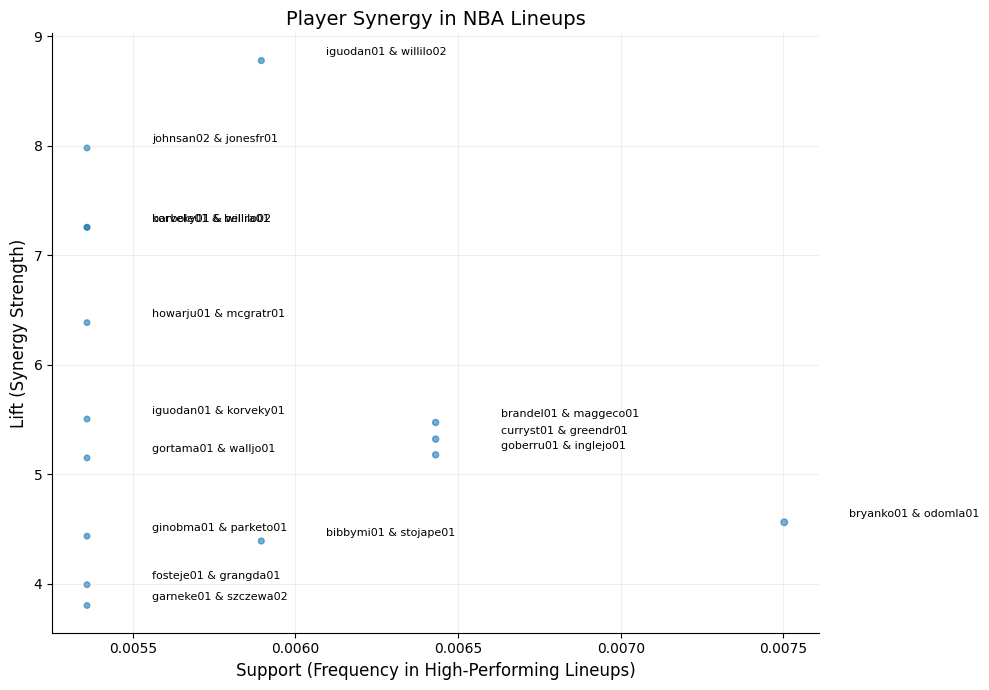

In [5]:

import matplotlib.pyplot as plt

# select top rules 
top_rules = rules_df.head(15).copy()

# label
top_rules["pair"] = top_rules["player_a"] + " & " + top_rules["player_b"]

# normalize bubble size
sizes = top_rules["support"] * 3000  # scale factor

# plot
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    top_rules["support"],
    top_rules["lift"],
    s=sizes,
    alpha=0.6
)

# add labels
for _, row in top_rules.iterrows():
    plt.text(
        row["support"] + 0.0002,
        row["lift"] + 0.05,
        row["pair"],
        fontsize=8
    )

# labels and title 
plt.xlabel("Support (Frequency in High-Performing Lineups)", fontsize=12)
plt.ylabel("Lift (Synergy Strength)", fontsize=12)
plt.title("Player Synergy in NBA Lineups", fontsize=14)

# style
plt.grid(alpha=0.2)

# remove top/right spines
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('./1.png')
plt.show()

